In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    SGDRegressor
)
from sklearn.metrics import (
    mean_squared_error, r2_score,
)
from sklearn.neighbors import KNeighborsClassifier

In [3]:
df_reg = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df_reg.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Pre- Processing

In [4]:
df_reg.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# Drop a specific column by name
df_reg = df_reg.drop(columns=['Id'])

## Missin value handle

In [7]:
# 1. Define your threshold (e.g., drop if > 50% is missing)
threshold = 0.4

# 2. Calculate the percentage of missing values per column
null_pct = df_reg.isnull().mean()

# 3. Identify columns to drop
cols_to_drop = null_pct[null_pct > threshold].index

# 4. Drop them
df_reg = df_reg.drop(columns=cols_to_drop)

print(f"Dropped columns: {list(cols_to_drop)}")

Dropped columns: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


In [8]:
# Identify numerical columns (integers and floats)
num_cols = df_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identify categorical columns (objects and category types)
cat_cols = df_reg.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

Numerical: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categorical: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond

In [9]:
# Identify categorical columns first
cat_cols = df_reg.select_dtypes(include=['object']).columns

# Print unique values for each
for col in cat_cols:
    print(f"--- {col} ---")
    print(df_reg[col].unique())

--- MSZoning ---
['RL' 'RM' 'C (all)' 'FV' 'RH']
--- Street ---
['Pave' 'Grvl']
--- LotShape ---
['Reg' 'IR1' 'IR2' 'IR3']
--- LandContour ---
['Lvl' 'Bnk' 'Low' 'HLS']
--- Utilities ---
['AllPub' 'NoSeWa']
--- LotConfig ---
['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
--- LandSlope ---
['Gtl' 'Mod' 'Sev']
--- Neighborhood ---
['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
--- Condition1 ---
['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
--- Condition2 ---
['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
--- BldgType ---
['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
--- HouseStyle ---
['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
--- RoofStyle ---
['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
--- RoofMatl ---
['CompShg' 'WdShngl' 'Me

In [10]:
# 1. Identify columns by type
float_cols = df_reg.select_dtypes(include=['float64']).columns
int_cols = df_reg.select_dtypes(include=['int64']).columns
obj_cols = df_reg.select_dtypes(include=['object']).columns

# 2. Apply Mean to Floats
for col in float_cols:
    df_reg[col] = df_reg[col].fillna(df_reg[col].mean())

# 3. Apply Median to Ints (The most suitable central measure for integers)
for col in int_cols:
    df_reg[col] = df_reg[col].fillna(df_reg[col].median())

# 4. Apply Mode (Max Frequency) to Objects
for col in obj_cols:
    # mode() returns a Series, so we take the first element [0]
    if not df_reg[col].mode().empty:
        df_reg[col] = df_reg[col].fillna(df_reg[col].mode()[0])

print("Null values handled.")

Null values handled.


In [11]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

## Remove highly correlated column

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

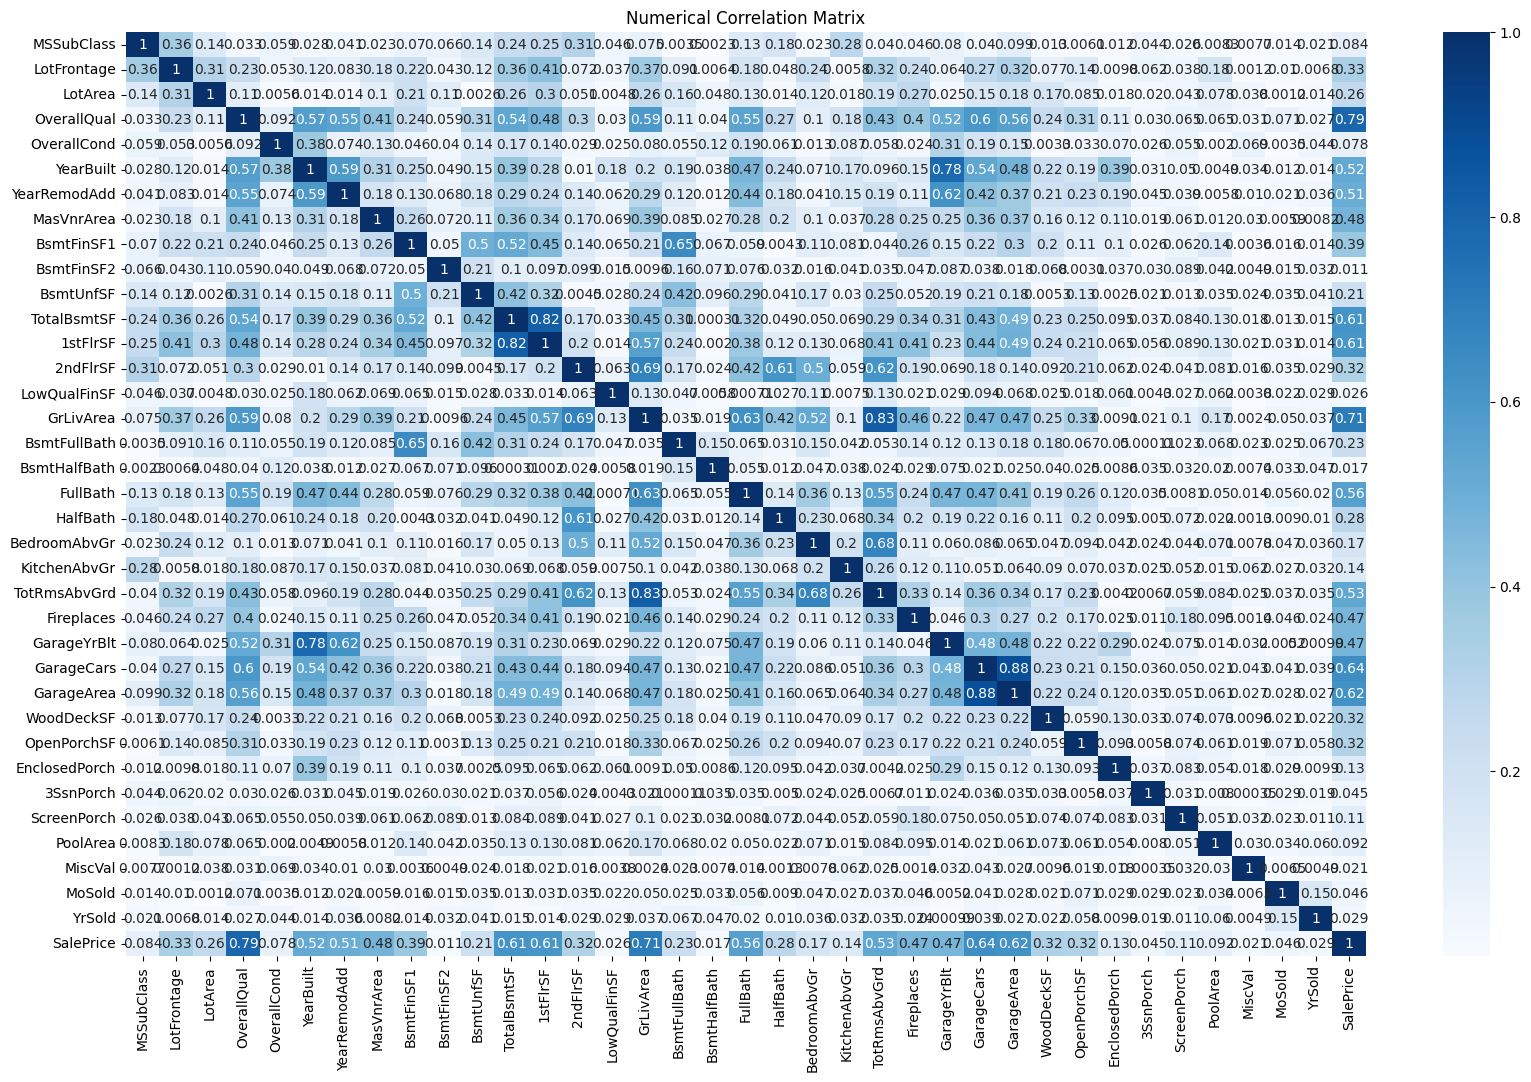

Dropped Numerical: ['OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'GarageCars']


In [13]:
# 1. Isolate Numerical Columns
df_num = df_reg.select_dtypes(include=[np.number])

# 2. Calculate and Show Matrix
num_corr = df_num.corr().abs()
plt.figure(figsize=(20, 12))
sns.heatmap(num_corr, annot=True, cmap='Blues')
plt.title("Numerical Correlation Matrix")
plt.show()

# 3. Identify and Remove
upper = num_corr.where(np.tril(np.ones(num_corr.shape), k=-1).astype(bool))
to_drop_num = [col for col in upper.columns if any(upper[col] > 0.75)]
df_reg = df_reg.drop(columns=to_drop_num)

print(f"Dropped Numerical: {to_drop_num}")
# as the target column was dropping when dropping the last

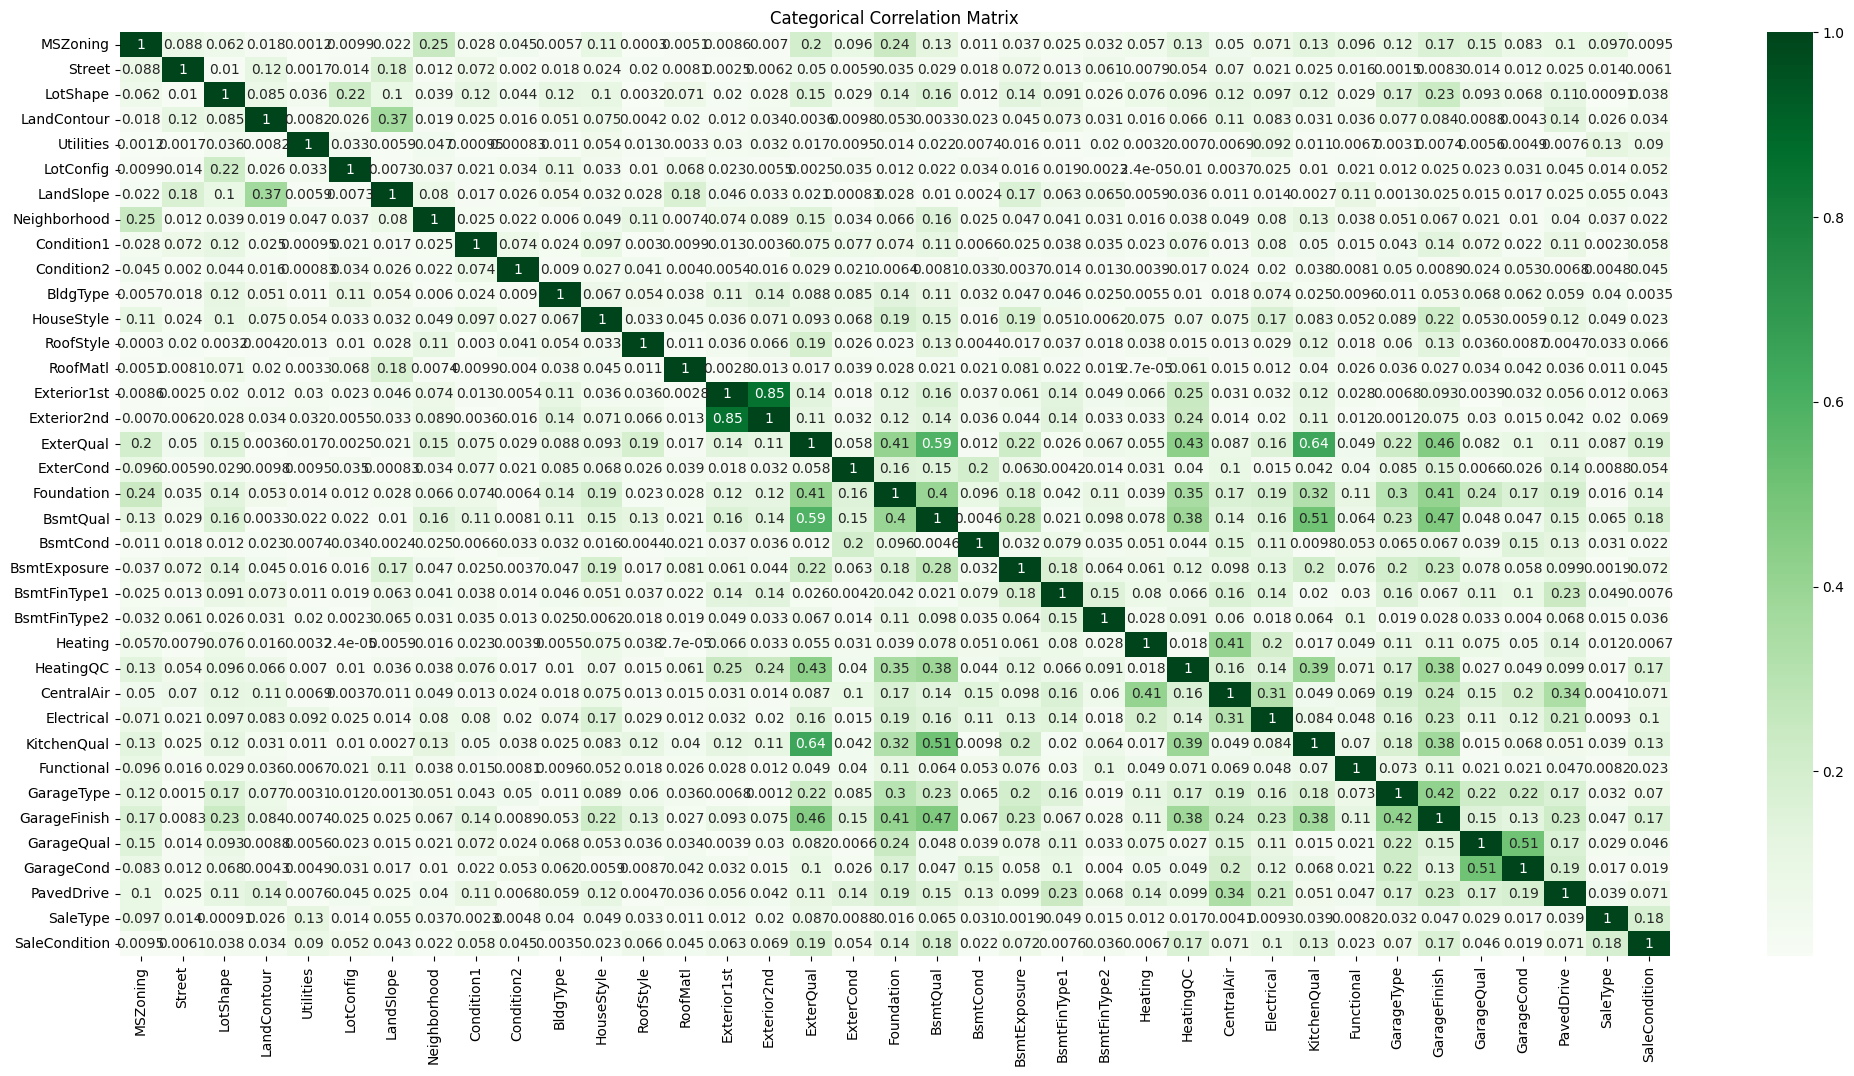

Dropped Categorical: ['Exterior2nd']


In [14]:
# 1. Isolate Categorical Columns
df_cat = df_reg.select_dtypes(include=['object']).copy()

# 2. Convert text to temporary codes for correlation check
for col in df_cat.columns:
    df_cat[col] = df_cat[col].astype('category').cat.codes

# 3. Calculate and Show Matrix
cat_corr = df_cat.corr().abs()
plt.figure(figsize=(25, 12))
sns.heatmap(cat_corr, annot=True, cmap='Greens')
plt.title("Categorical Correlation Matrix")
plt.show()

# 4. Identify and Remove
upper_cat = cat_corr.where(np.triu(np.ones(cat_corr.shape), k=1).astype(bool))
to_drop_cat = [col for col in upper_cat.columns if any(upper_cat[col] > 0.75)]
df_reg = df_reg.drop(columns=to_drop_cat)

print(f"Dropped Categorical: {to_drop_cat}")

## Drop Outlier

In [15]:
# 1. Select integer columns
int_cols = df_reg.select_dtypes(include=['int64','float64'])

# 2. Get min and max, then transpose
summary = int_cols.describe().loc[['min', 'max']].T

# 3. Add a calculated Range column
summary['range'] = summary['max'] - summary['min']

# 4. Rename columns for better headers
summary.columns = ['Minimum', 'Maximum', 'Range']

print("--- Integer Column Ranges ---")
print(summary)

--- Integer Column Ranges ---
               Minimum   Maximum     Range
MSSubClass        20.0     190.0     170.0
LotFrontage       21.0     313.0     292.0
LotArea         1300.0  215245.0  213945.0
OverallCond        1.0       9.0       8.0
YearRemodAdd    1950.0    2010.0      60.0
MasVnrArea         0.0    1600.0    1600.0
BsmtFinSF1         0.0    5644.0    5644.0
BsmtFinSF2         0.0    1474.0    1474.0
BsmtUnfSF          0.0    2336.0    2336.0
1stFlrSF         334.0    4692.0    4358.0
2ndFlrSF           0.0    2065.0    2065.0
LowQualFinSF       0.0     572.0     572.0
BsmtFullBath       0.0       3.0       3.0
BsmtHalfBath       0.0       2.0       2.0
FullBath           0.0       3.0       3.0
HalfBath           0.0       2.0       2.0
BedroomAbvGr       0.0       8.0       8.0
KitchenAbvGr       0.0       3.0       3.0
TotRmsAbvGrd       2.0      14.0      12.0
Fireplaces         0.0       3.0       3.0
GarageYrBlt     1900.0    2010.0     110.0
GarageArea         0.0  

In [16]:
# 1. Identify numerical columns
num_cols = df_reg.select_dtypes(include=[np.number]).columns

# Record the starting number of rows
initial_rows = len(df_reg)
print(f"Total rows in dataset before cleaning: {initial_rows}")
print("-" * 30)

for col in num_cols:
    rows_before = len(df_reg)
    
    # 2. Calculate IQR
    Q1 = df_reg[col].quantile(0.15)
    Q3 = df_reg[col].quantile(0.85)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # 3. Filter (Drop the outliers)
    df_reg = df_reg[(df_reg[col] >= lower) & (df_reg[col] <= upper)]
    
    rows_after = len(df_reg)
    rows_dropped = rows_before - rows_after
    
    if rows_dropped > 0:
        print(f"Column '{col}': Dropped {rows_dropped} rows")

# 4. Final Summary
final_rows = len(df_reg)
total_dropped = initial_rows - final_rows
print("-" * 30)
print(f"Cleaning Complete.")
print(f"Final row count: {final_rows}")
print(f"Total rows removed: {total_dropped} ({(total_dropped/initial_rows)*100:.2f}% of data)")

Total rows in dataset before cleaning: 1460
------------------------------
Column 'LotFrontage': Dropped 16 rows
Column 'LotArea': Dropped 30 rows
Column 'OverallCond': Dropped 1 rows
Column 'MasVnrArea': Dropped 29 rows
Column 'BsmtFinSF2': Dropped 157 rows
Column '1stFlrSF': Dropped 1 rows
Column 'LowQualFinSF': Dropped 23 rows
Column 'BsmtFullBath': Dropped 1 rows
Column 'BsmtHalfBath': Dropped 55 rows
Column 'KitchenAbvGr': Dropped 58 rows
Column 'Fireplaces': Dropped 3 rows
Column 'GarageArea': Dropped 1 rows
Column 'WoodDeckSF': Dropped 11 rows
Column 'OpenPorchSF': Dropped 11 rows
Column 'EnclosedPorch': Dropped 148 rows
Column '3SsnPorch': Dropped 17 rows
Column 'ScreenPorch': Dropped 73 rows
Column 'PoolArea': Dropped 1 rows
Column 'MiscVal': Dropped 23 rows
Column 'SalePrice': Dropped 2 rows
------------------------------
Cleaning Complete.
Final row count: 799
Total rows removed: 661 (45.27% of data)


## Train-test split

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [18]:
# 1. Separate Features and Target
X = df_reg.drop(columns=['SalePrice'])
y = df_reg['SalePrice']

# 2. Simple Train-Test Split (no stratification)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Identify Column Types
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# 4. Create the Transformer
# This applies scaling to numbers and one-hot encoding to categories
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 5. Fit on Train, Transform both (Prevents Data Leakage)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [19]:
X_train_r = X_train_transformed
X_test_r = X_test_transformed
y_train_r = y_train
y_test_r = y_test

In [20]:
# Regression Evaluation Function
def evaluate_regression(model):
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    
    print("R2 Score:", r2_score(y_test_r, y_pred))
    print("MSE:", mean_squared_error(y_test_r, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred)))
    print("-"*40)

# Multiple Linear Regression (MLR)


In [21]:
lr = LinearRegression()
evaluate_regression(lr)

R2 Score: 0.8923858691007972
MSE: 513591138.0110353
RMSE: 22662.54923902065
----------------------------------------


# Ridge Regression

In [22]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
evaluate_regression(ridge)

R2 Score: 0.9111736023059954
MSE: 423926210.20946795
RMSE: 20589.468429502205
----------------------------------------


# Lasso Regression

In [23]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
evaluate_regression(lasso)

R2 Score: 0.8925009765697225
MSE: 513041784.72940856
RMSE: 22650.42570746538
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.349e+10, tolerance: 3.149e+08
  model = cd_fast.enet_coordinate_descent(


# ElasticNet

In [24]:
# ElasticNet
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
evaluate_regression(elastic)

R2 Score: 0.9087639883735008
MSE: 435426153.1204624
RMSE: 20866.867352826644
----------------------------------------


# Polynomial Regression

In [25]:
# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_r)
X_poly_test = poly.transform(X_test_r)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train_r)

y_pred_poly = poly_model.predict(X_poly_test)

print("Polynomial R2:", r2_score(y_test_r, y_pred_poly))

Polynomial R2: 0.8742480988947346


# SGD Regressor

In [26]:
# SGD Regressor
sgd_reg = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.001)
evaluate_regression(sgd_reg)

R2 Score: 0.9164778254326954
MSE: 398611672.3402923
RMSE: 19965.26163966534
----------------------------------------


# KNN

In [27]:
from sklearn.neighbors import KNeighborsRegressor

# n_neighbors=5 is the standard starting point
knn_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform')

# Evaluate using your custom function
evaluate_regression(knn_reg)

R2 Score: 0.8566200573071139
MSE: 684284371.581
RMSE: 26158.829705875603
----------------------------------------


# SVM

In [28]:
from sklearn.svm import SVR

# C controls regularization; epsilon defines the "margin of error"
svm_reg = SVR(kernel='rbf', C=100000, epsilon=0.1)

# Evaluate using your custom function
evaluate_regression(svm_reg)

R2 Score: 0.9289674728495477
MSE: 339004516.8805131
RMSE: 18412.075300750676
----------------------------------------


# XGBoost

In [29]:
from xgboost import XGBRegressor

# Initialize the model
# n_estimators: number of trees
# max_depth: how deep each tree can go
# learning_rate: step size shrinkage to prevent overfitting
xgb_reg = XGBRegressor(
    n_estimators=100, 
    max_depth=7, 
    learning_rate=0.1, 
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores
)

# Evaluate using your custom function
evaluate_regression(xgb_reg)

R2 Score: 0.867977499961853
MSE: 630080768.0
RMSE: 25101.40968152984
----------------------------------------
